# Cascaded Generation

Generate a coarse image with the autoregressive transformer, then refine it with reverse diffusion. The VQ-VAE output is treated as $x_0$, corrupted to timestep $t$ via the forward process, then denoised — producing an image that shares the coarse structure of the GPT output but with details filled in by the diffusion model.

In [12]:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128

import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [13]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'using {device}')

using cuda


## Models

All model definitions are reproduced here so the notebook is self-contained.

### VQ-VAE

In [14]:
class ResBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(d, d, 3, padding=1),
            nn.GroupNorm(8, d),
            nn.ReLU(),
            nn.Conv2d(d, d, 3, padding=1),
            nn.GroupNorm(8, d),
        )
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(x + self.block(x))


class Encoder(nn.Module):
    def __init__(self, d=64):
        super().__init__()
        self.conv1 = nn.Conv2d(3, d, 4, padding=1, stride=2)
        self.conv2 = nn.Conv2d(d, d, 4, padding=1, stride=2)
        self.act   = nn.ReLU()
        self.res1  = ResBlock(d)
        self.res2  = ResBlock(d)

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.res1(x)
        x = self.res2(x)
        return x


class Decoder(nn.Module):
    def __init__(self, d=64):
        super().__init__()
        self.res1   = ResBlock(d)
        self.res2   = ResBlock(d)
        self.convt1 = nn.ConvTranspose2d(d, d, 4, padding=1, stride=2)
        self.convt2 = nn.ConvTranspose2d(d, 3, 4, padding=1, stride=2)
        self.act    = nn.ReLU()

    def forward(self, x):
        x = self.res1(x)
        x = self.res2(x)
        x = self.act(self.convt1(x))
        x = self.convt2(x)
        return x


class VectorQuantizer(nn.Module):
    def __init__(self, K=512, d=64, gamma=0.99, eps=1e-5):
        super().__init__()
        self.K = K
        self.d = d
        self.register_buffer('codebook', torch.randn(K, d))
        self.register_buffer('ema_cluster_size', torch.zeros(K))
        self.register_buffer('ema_embed_sum', torch.randn(K, d))

    def forward(self, z_e):
        B, C, H, W = z_e.shape
        z_e_flat = z_e.view(B, C, -1).transpose(1, 2).contiguous()
        dists = torch.cdist(z_e_flat, self.codebook)
        idx   = torch.argmin(dists, dim=2)
        z_q   = self.codebook[idx]
        z_q   = z_q.transpose(1, 2).contiguous().view(B, C, H, W)
        z_q_st = z_e + (z_q - z_e).detach()
        return z_q_st, z_q, idx.view(B, H, W)


class VQVAE(nn.Module):
    def __init__(self, K=512, d=64):
        super().__init__()
        self.enc = Encoder(d)
        self.vq  = VectorQuantizer(K, d)
        self.dec = Decoder(d)

    def forward(self, x):
        z_e              = self.enc(x)
        z_q_st, z_q, idx = self.vq(z_e)
        x_hat            = self.dec(z_q_st)
        return x_hat, z_e, z_q, idx

### Autoregressive Transformer

In [15]:
def positional_encoding(pos, n_cols, d_model):
    d    = d_model // 2
    half = d // 2
    freqs    = torch.exp(-math.log(10000) * torch.arange(half) / half)
    row_pos  = pos // n_cols
    col_pos  = pos % n_cols
    row_args = row_pos.float().view(-1, 1) @ freqs.view(1, -1)
    col_args = col_pos.float().view(-1, 1) @ freqs.view(1, -1)
    return torch.cat([row_args.sin(), row_args.cos(), col_args.sin(), col_args.cos()], dim=1)


class GPT(nn.Module):
    def __init__(self, K=512, S=8, d_model=256, nhead=8, num_layers=8):
        super().__init__()
        self.K = K
        self.token_emb = nn.Embedding(K, d_model)
        self.label_emb = nn.Embedding(10, d_model)
        pos_encoding = positional_encoding(torch.arange(0, S*S - 1), S, d_model)
        self.register_buffer('pos_encoding', pos_encoding)
        self.register_buffer('mask', torch.tril(torch.ones(S*S, S*S, dtype=torch.bool)))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.linear = nn.Linear(d_model, K)

    def forward(self, seq):
        l_emb = self.label_emb(seq[:, :1])
        t_emb = self.token_emb(seq[:, 1:]) + self.pos_encoding
        x     = torch.cat([l_emb, t_emb], dim=1)
        out   = self.transformer(x, mask=self.mask, is_causal=True)
        return self.linear(out)

### UNet

In [16]:
def sinusoidal_embedding(t, dim):
    half  = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    args  = t[:, None].float() * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=-1)


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1     = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2     = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1     = nn.GroupNorm(8, out_ch)
        self.norm2     = nn.GroupNorm(8, out_ch)
        self.act       = nn.ReLU()
        self.time_proj = nn.Linear(time_dim, out_ch)

    def forward(self, x, t_emb):
        x = self.act(self.norm1(self.conv1(x)))
        x = x + self.time_proj(t_emb)[:, :, None, None]
        x = self.act(self.norm2(self.conv2(x)))
        return x


class UNet(nn.Module):
    def __init__(self, in_ch=3, base_ch=64, time_dim=128, n_labels=10):
        super().__init__()
        self.time_dim  = time_dim
        self.time_mlp  = nn.Sequential(nn.Linear(time_dim, time_dim * 4), nn.ReLU(), nn.Linear(time_dim * 4, time_dim))
        self.label_emb = nn.Embedding(n_labels, time_dim)
        self.enc1 = Block(in_ch,     base_ch,     time_dim)
        self.enc2 = Block(base_ch,   base_ch * 2, time_dim)
        self.enc3 = Block(base_ch*2, base_ch * 4, time_dim)
        self.down = nn.MaxPool2d(2)
        self.bot  = Block(base_ch*4, base_ch * 4, time_dim)
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec3 = Block(base_ch*4 + base_ch*4, base_ch * 2, time_dim)
        self.dec2 = Block(base_ch*2 + base_ch*2, base_ch,     time_dim)
        self.dec1 = Block(base_ch   + base_ch,   base_ch,     time_dim)
        self.out  = nn.Conv2d(base_ch, in_ch, 1)

    def forward(self, x, t, label):
        H, W  = x.shape[2], x.shape[3]
        pad_h = (8 - H % 8) % 8
        pad_w = (8 - W % 8) % 8
        x     = nn.functional.pad(x, (0, pad_w, 0, pad_h))
        t_emb = self.time_mlp(sinusoidal_embedding(t, self.time_dim)) + self.label_emb(label)
        s1 = self.enc1(x,             t_emb)
        s2 = self.enc2(self.down(s1), t_emb)
        s3 = self.enc3(self.down(s2), t_emb)
        b  = self.bot(self.down(s3),  t_emb)
        x  = self.dec3(torch.cat([self.up(b), s3], dim=1), t_emb)
        x  = self.dec2(torch.cat([self.up(x), s2], dim=1), t_emb)
        x  = self.dec1(torch.cat([self.up(x), s1], dim=1), t_emb)
        return self.out(x)[:, :, :H, :W]

## Load Checkpoints

In [17]:
K, d, S = 512, 64, 8

vqvae = VQVAE(K=K, d=d).to(device)
vqvae.load_state_dict(torch.load('data/vqvae_cifar10_latest.pt', map_location=device))
vqvae.eval()

gpt = GPT(K=K, S=S).to(device)
gpt.load_state_dict(torch.load('data/gpt_cifar10_large_latest.pt', map_location=device))
# keep GPT in train mode — eval mode triggers a CUDA fast-path that conflicts with is_causal + bool mask

unet = UNet(in_ch=3).to(device)
unet.load_state_dict(torch.load('data/unet_cifar10_large_latest.pt', map_location=device))
unet.eval()

print('all checkpoints loaded')

all checkpoints loaded


## Noise Schedule

In [18]:
T          = 1000
betas      = torch.linspace(1e-4, 0.02, T).to(device)
alphas     = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

def forward(x0, t):
    ab  = alpha_bars[t].view(-1, 1, 1, 1)
    eps = torch.randn_like(x0)
    return ab.sqrt() * x0 + (1 - ab).sqrt() * eps

In [19]:
@torch.no_grad()
def sample(labels):
    n = labels.shape[0]
    xt = torch.randn(n, 3, 32, 32, device=device)
    for t in tqdm(reversed(range(T)), total=T, desc='sampling', leave=False):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        ab      = alpha_bars[t]
        ab_prev = alpha_bars[t - 1] if t > 0 else torch.tensor(1.0, device=device)
        beta    = betas[t]; alpha = alphas[t]
        eps_pred = unet(xt, t_batch, labels)
        x0_hat   = (xt - (1 - ab).sqrt() * eps_pred) / ab.sqrt()
        x0_hat   = x0_hat.clamp(-1, 1)
        mu  = (ab_prev.sqrt() * beta / (1 - ab)) * x0_hat \
            + (alpha.sqrt() * (1 - ab_prev) / (1 - ab)) * xt
        var = beta * (1 - ab_prev) / (1 - ab)
        noise = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)
        xt    = mu + var.sqrt() * noise
    return (xt + 1) / 2

## Cascaded Generation

The pipeline:
1. GPT samples a token sequence conditioned on the class label
2. VQ-VAE decodes it into a coarse $32 \times 32$ image $x_0^{\text{coarse}}$
3. The forward process corrupts it to $x_{t_{\text{start}}}$
4. Reverse diffusion denoises from $t_{\text{start}}$ down to $0$

Lower $t_{\text{start}}$ stays closer to the GPT output; higher $t_{\text{start}}$ gives diffusion more freedom to reshape it.

In [20]:
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

@torch.no_grad()
def cascade(labels, t_start=500, temperature=1.0):
    B = labels.shape[0]

    # GPT -> VQ-VAE
    x = torch.cat([labels.view(B, 1), torch.zeros(B, S*S, dtype=torch.long, device=device)], dim=1)
    for i in tqdm(range(S*S), desc='generating tokens', leave=False):
        logits = gpt(x[:, :-1])[:, i, :] / temperature
        probs  = nn.functional.softmax(logits, dim=1)
        x[:, i+1] = torch.multinomial(probs, 1).squeeze()
    z_q = vqvae.vq.codebook[x[:, 1:]]
    z_q = z_q.transpose(1, 2).contiguous().view(B, d, S, S)
    x0_coarse = vqvae.dec(z_q)  # [-1, 1]

    # corrupt to t_start
    t_tensor = torch.full((B,), t_start - 1, device=device, dtype=torch.long)
    xt = forward(x0_coarse, t_tensor)

    # reverse diffusion from t_start
    for t in tqdm(reversed(range(t_start)), total=t_start, desc='denoising', leave=False):
        t_batch  = torch.full((B,), t, device=device, dtype=torch.long)
        ab       = alpha_bars[t]
        ab_prev  = alpha_bars[t - 1] if t > 0 else torch.tensor(1.0, device=device)
        beta     = betas[t]
        alpha    = alphas[t]
        eps_pred = unet(xt, t_batch, labels)
        x0_hat   = (xt - (1 - ab).sqrt() * eps_pred) / ab.sqrt()
        x0_hat   = x0_hat.clamp(-1, 1)
        mu  = (ab_prev.sqrt() * beta / (1 - ab)) * x0_hat \
            + (alpha.sqrt() * (1 - ab_prev) / (1 - ab)) * xt
        var = beta * (1 - ab_prev) / (1 - ab)
        noise = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)
        xt    = mu + var.sqrt() * noise

    return (x0_coarse + 1) / 2, (xt + 1) / 2

## Results

Comparing autoregressive-only, diffusion-only, and cascade at increasing $t_{\text{start}}$. Smaller $t_{\text{start}}$ stays closer to the GPT structure; larger values let diffusion reshape more.

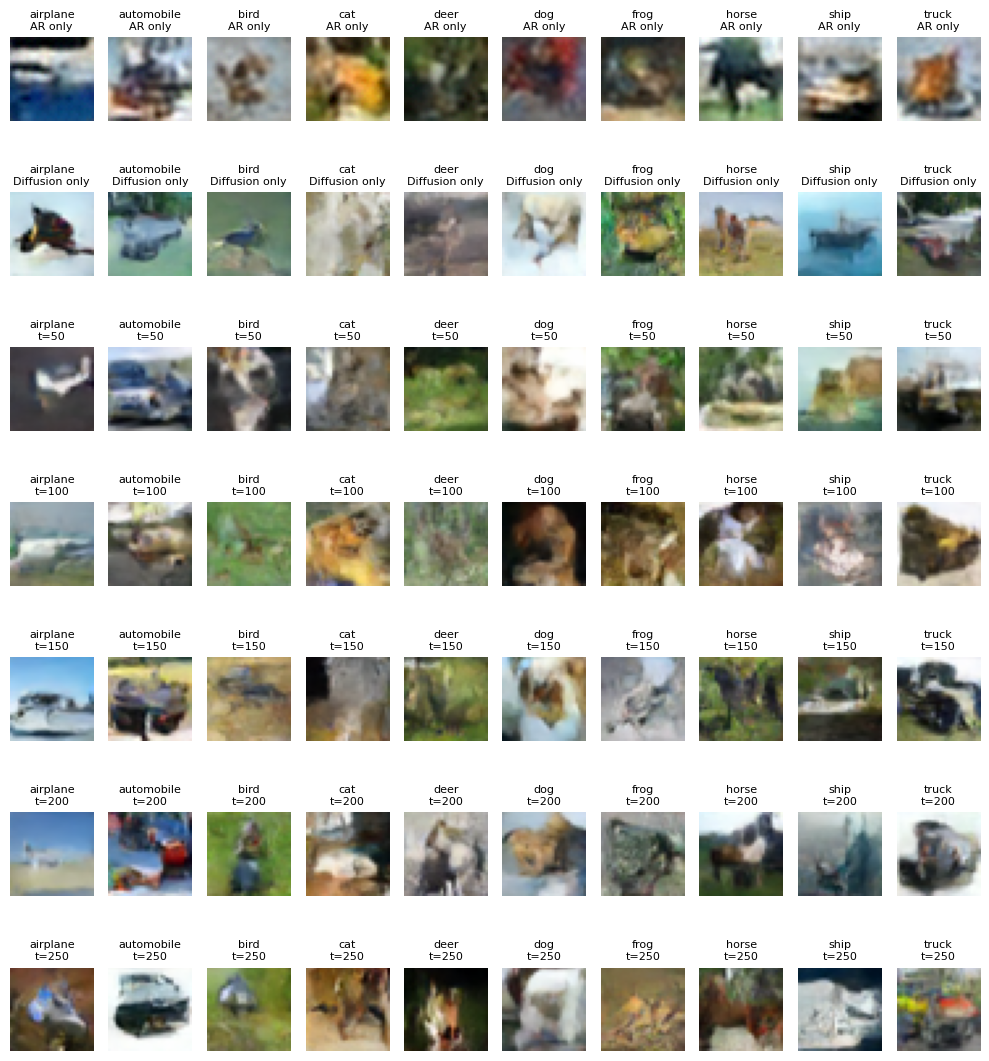

In [21]:
t_values = [50, 100, 150, 200, 250]
labels   = torch.arange(10, dtype=torch.long, device=device)

rows = []
coarse, _ = cascade(labels, t_start=t_values[0])
rows.append(('AR only',        coarse))
rows.append(('Diffusion only', sample(labels)))
for t_start in t_values:
    _, refined = cascade(labels, t_start=t_start)
    rows.append((f't={t_start}', refined))

fig, axes = plt.subplots(len(rows), 10, figsize=(10, len(rows) * 1.6))
for row_idx, (row_label, imgs) in enumerate(rows):
    for col in range(10):
        axes[row_idx, col].imshow(imgs[col].cpu().permute(1, 2, 0).clamp(0, 1))
        axes[row_idx, col].set_title(f'{CLASSES[col]}\n{row_label}', fontsize=8)
        axes[row_idx, col].axis('off')
plt.tight_layout()
plt.show()